# 04 - Logistic Regression PD Model

## Credit Risk Modelling Using Logistic Regression

This notebook estimates the Probability of Default for serious delinquency within two years with logistic regression. It uses a stratified train/test split, learns scaling values from training data, and reports training-sample coefficient inference. The holdout is reserved for Stage 5.

## Model definition

For borrower $i$, let $Y_i=1$ indicate serious delinquency within two years. The model assumes

$$
Y_i \sim \operatorname{Bernoulli}(p_i),
\qquad
\log\left(\frac{p_i}{1-p_i}\right)
=
\beta_0+\sum_{j=1}^{k}\beta_j X_{ij}.
$$

Thus, the fitted probability $\hat p_i$ is the borrower's estimated **Probability of Default (PD)**. Coefficients are estimated by maximum likelihood using statsmodels. Predictors are standardized using training-sample means and standard deviations; odds ratios therefore describe a one-standard-deviation increase in a predictor, holding the other model predictors fixed. These are conditional associations, not causal effects.

## 1. Prepare predictors and reserve a holdout

The target and two Stage 3 features are prepared through the reusable modules. The composite delinquency count is used in place of the three highly overlapping delinquency counts. Scaling parameters are learned after the split from the training partition only. The fixed random seed makes the split reproducible.

In [1]:
import sys
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, "../src")
from model import prepare_data, split_data, scale_data, fit_logit, coefficient_table

DATA_PATH = "../data/processed/cleaned_data.csv"
MODEL_PATH = "../models/logistic_regression.pkl"
FIG_PATH = "../reports/figures/stage4_odds_ratios.png"
SEED = 42

clean_data = pd.read_csv(DATA_PATH)
feat, target = prepare_data(clean_data)
train_feat, test_feat, train_y, test_y = split_data(feat, target, SEED)
scaler, train_scaled, test_scaled = scale_data(train_feat, test_feat)

split_tab = pd.DataFrame({
    "partition": ["Training", "Holdout"],
    "borrowers": [len(train_y), len(test_y)],
    "defaults": [int(train_y.sum()), int(test_y.sum())],
    "default_rate_percent": [train_y.mean() * 100, test_y.mean() * 100],
})
display(split_tab.round({"default_rate_percent": 3}))
print(f"Predictors: {len(feat.columns)}")
print("Holdout is reserved for Stage 5 and is not used to estimate coefficients.")

,partition,borrowers,defaults,default_rate_percent
0,Training,101893,6882,6.754
1,Holdout,43669,2949,6.753


Predictors: 8
Holdout is reserved for Stage 5 and is not used to estimate coefficients.


## 2. Fit the logistic regression on training data

An intercept is included in the design matrix. The model uses the eight specified predictors and no holdout observations. Statistical tests and intervals below rely on the usual maximum-likelihood large-sample approximation.

In [2]:
fit_result = fit_logit(train_scaled, train_y)
coef_tab = coefficient_table(fit_result)
display(coef_tab.round({
    "coefficient": 4,
    "std_error": 4,
    "z_value": 3,
    "p_value": 6,
    "ci_lower": 4,
    "ci_upper": 4,
    "odds_ratio_per_sd": 4,
    "or_ci_lower": 4,
    "or_ci_upper": 4,
}))
print(f"Converged: {fit_result.mle_retvals['converged']}")
print(f"Training log-likelihood: {fit_result.llf:,.2f}")
print(f"Training observations: {int(fit_result.nobs):,}")

,coefficient,std_error,z_value,p_value,ci_lower,ci_upper,odds_ratio_per_sd,or_ci_lower,or_ci_upper
const,-2.7365,0.0138,-198.504,0.000000,-2.7635,-2.7095,0.0648,0.0631,0.0666
age,-0.4506,0.0144,-31.295,0.000000,-0.4788,-0.4224,0.6372,0.6195,0.6555
RevolvingUtilizationOfUnsecuredLines,-0.0082,0.0160,-0.509,0.610755,-0.0396,0.0233,0.9919,0.9612,1.0235
DebtRatio,-0.0116,0.0214,-0.543,0.586934,-0.0536,0.0303,0.9884,0.9478,1.0308
LogMonthlyIncome,-0.0129,0.0122,-1.054,0.291671,-0.0368,0.0111,0.9872,0.9638,1.0111
TotalDelinquencies,0.1480,0.0085,17.438,0.000000,0.1314,0.1646,1.1595,1.1404,1.1790
NumberOfOpenCreditLinesAndLoans,-0.0359,0.0152,-2.360,0.018284,-0.0657,-0.0061,0.9648,0.9364,0.9939
NumberRealEstateLoansOrLines,0.0053,0.0149,0.357,0.721021,-0.0239,0.0345,1.0053,0.9764,1.0351
NumberOfDependents,0.0988,0.0118,8.390,0.000000,0.0757,0.1219,1.1038,1.0786,1.1296


Converged: True
Training log-likelihood: -24,241.18
Training observations: 101,893


## 3. Interpret coefficients and odds ratios

For a standardized predictor $X_j$, $\exp(\hat{\beta}_j)$ is the estimated multiplicative change in the odds of serious delinquency associated with a one-standard-deviation increase, conditional on the other included predictors. Values above 1 indicate higher fitted odds; values below 1 indicate lower fitted odds. A 95% confidence interval for the odds ratio is obtained by exponentiating the coefficient interval.

Small p-values indicate evidence against a zero coefficient under the model and sampling assumptions. They do not establish causation or practical importance. Correlated predictors, extreme records, omitted variables, and functional-form misspecification can affect these estimates.

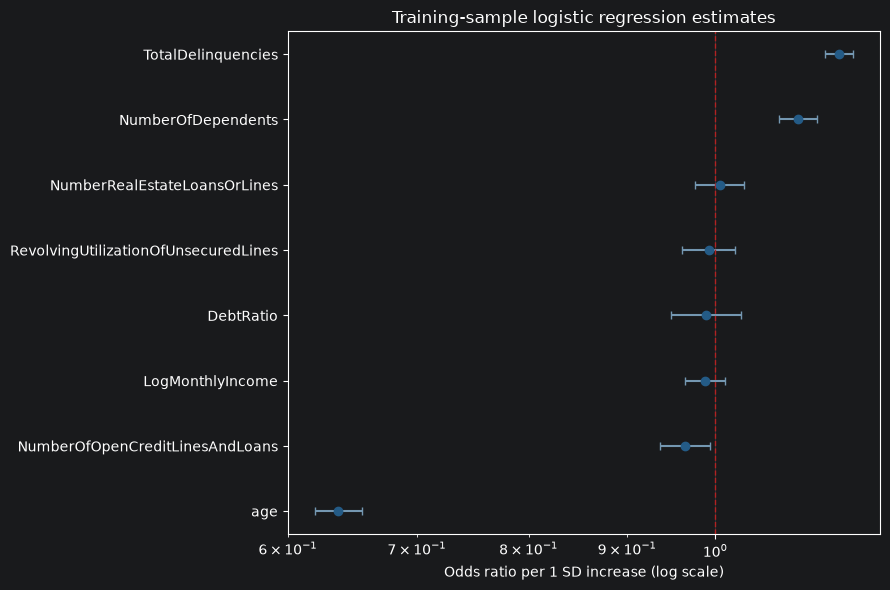

Saved coefficient figure to ../reports/figures/stage4_odds_ratios.png


In [3]:
or_tab = coef_tab.drop(index="const").sort_values("odds_ratio_per_sd")
pos = range(len(or_tab))
fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    or_tab["odds_ratio_per_sd"],
    pos,
    xerr=[
        or_tab["odds_ratio_per_sd"] - or_tab["or_ci_lower"],
        or_tab["or_ci_upper"] - or_tab["odds_ratio_per_sd"],
    ],
    fmt="o",
    color="#245b86",
    ecolor="#7497b1",
    capsize=3,
)
ax.axvline(1, color="#b22222", linestyle="--", linewidth=1)
ax.set_yticks(list(pos))
ax.set_yticklabels(or_tab.index)
ax.set_xscale("log")
ax.set_xlabel("Odds ratio per 1 SD increase (log scale)")
ax.set_title("Training-sample logistic regression estimates")
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
os.makedirs("../reports/figures", exist_ok=True)
fig.savefig(FIG_PATH, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved coefficient figure to {FIG_PATH}")

## 4. Save the fitted model for Stage 5

Save the training-fitted coefficients, predictor names, training-only scaling values, and split seed together. Stage 5 can reproduce the same stratified holdout, transform it with the training scaler, and assess discrimination, calibration, and risk deciles without refitting on holdout outcomes.

In [4]:
os.makedirs("../models", exist_ok=True)
model_pack = {
    "coef": fit_result.params.to_dict(),
    "scale_mean": scaler.mean_.tolist(),
    "scale_std": scaler.scale_.tolist(),
    "features": list(feat.columns),
    "seed": SEED,
}
with open(MODEL_PATH, "wb") as model_file:
    pickle.dump(model_pack, model_file)
print(f"Saved training-fitted model package to {MODEL_PATH}")

Saved training-fitted model package to ../models/logistic_regression.pkl


## Stage 4 interpretation

- The stratified split contains **101,893 training borrowers** (6.754% defaults) and **43,669 holdout borrowers** (6.753%). The holdout remains reserved for Stage 5 performance assessment.
- The maximum-likelihood fit **converged** on the training sample (n=101,893).
- Holding the other included predictors fixed, a one-standard-deviation increase in age is associated with lower estimated odds of serious delinquency (**OR 0.637**, 95% CI 0.620–0.656). The total-delinquency count is associated with higher odds (**OR 1.160**, 95% CI 1.140–1.179), as is number of dependents (**OR 1.104**, 95% CI 1.079–1.130).
- Number of open credit lines has a small **nominally significant** negative conditional association (**OR 0.965**, 95% CI 0.936–0.994; unadjusted p=0.018). The p-value is not adjusted for examining multiple coefficients, so treat this as weaker evidence. Its practical meaning and functional form need further scrutiny.
- The linear terms for revolving utilization, debt ratio, log income, and real-estate loans are **not statistically distinguishable from zero at the 5% level** in this specification; their 95% odds-ratio intervals include 1. This does not negate the Stage 3 group patterns. In particular, a single linear term may not capture the evident nonlinear utilization pattern, and extreme tails may influence the estimates.
- Predictors are standardized, so each odds ratio refers to one training-sample standard deviation, not one original unit. Significance is not evidence of causation or of out-of-sample usefulness.
- Stage 5 must assess the reserved holdout, calibration, discrimination, logit functional form, multicollinearity, and influential observations. No holdout performance metric is reported here.

The saved model package contains fitted coefficients and training-only scaling values for reproducible holdout scoring.